<a href="https://colab.research.google.com/github/KevinUz05/KevinUz05.github.io/blob/main/Proyecto_Probabilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import scipy.integrate as integrate
from scipy.special import gamma as Gamma
import scipy.stats as stats 

def normal(x, mu=0, sigma=1):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

def t_dist(x, df):

    num = Gamma((df + 1) / 2)
    den = np.sqrt(df * np.pi) * Gamma(df / 2)
    return (num / den) * (1 + (x**2) / df)**(-(df + 1) / 2)

def f_dist(x, df1, df2):

    if x <= 0: return 0.0
    num = ( (df1/df2)**(df1/2) * x**(df1/2 - 1) * Gamma((df1+df2)/2) )
    den = ( Gamma(df1/2) * Gamma(df2/2) * (1 + (df1/df2)*x)**((df1+df2)/2) )
    return num / den

def chi2_dist(x, df):
    if x <= 0: return 0.0
    return (x**(df/2 - 1) * np.exp(-x/2)) / (2**(df/2) * Gamma(df/2))


def SSA(k, n_dims, yi_mean, y_mean):
    return np.sum([n_dims[i] * (yi_mean[i] - y_mean)**2 for i in range(k)])

def SSE(k, g_tot, yi_mean):
    return np.sum([np.sum((g_tot[i] - yi_mean[i])**2) for i in range(k)])

def SST(k, n_dims, g_tot, y_mean):
    return np.sum([np.sum((g_tot[i] - y_mean)**2) for i in range(k)])


df = pd.read_csv('student_lifestyle.csv')

print("\n--- 2. T-STUDENT: EVALUACIÓN PAREADA DE TIEMPOS (Study_Hours vs Screen_Time) ---")
diferencias = df['Study_Hours_per_Day'].values - df['Screen_Time_Hours'].values
n_dif = len(diferencias)
df_t = n_dif - 1

media_dif = np.mean(diferencias)
desv_dif = np.std(diferencias, ddof=1)
t_exp = media_dif / (desv_dif / np.sqrt(n_dif))


t_critico = stats.t.ppf(0.975, df_t)

print(f"Estadístico t Experimental: {t_exp:.4f}")
print(f"Valor Crítico t de Tabla (Integrado): {t_critico:.4f}")
if abs(t_exp) > t_critico:
    print("Resultado: Se RECHAZA H0. Existe un desbalance de tiempo significativo que afectará el peso en la regresión.")
else:
    print("Resultado: NO se rechaza H0. Ambas variables consumen el tiempo equitativamente.")


print("\n--- 3. ANOVA: EVALUACIÓN DEL IMPACTO DE 'Stress_Level' SOBRE EL 'CGPA' ---")

grupo_bajo = df[df['Stress_Level_1_to_10'] <= 4]['CGPA'].values
grupo_medio = df[(df['Stress_Level_1_to_10'] > 4) & (df['Stress_Level_1_to_10'] <= 7)]['CGPA'].values
grupo_alto = df[df['Stress_Level_1_to_10'] > 7 ]['CGPA'].values
g_tot = [grupo_bajo, grupo_medio, grupo_alto]

k = len(g_tot)
n_dims = [len(g) for g in g_tot]
yi_mean = np.array([np.mean(g) for g in g_tot])
all_data = np.concatenate(g_tot)
y_mean = np.mean(all_data)

SSA_val = SSA(k, n_dims, yi_mean, y_mean)
SSE_val = SSE(k, g_tot, yi_mean)
SST_val = SST(k, n_dims, g_tot, y_mean)

df1_f = k - 1
df2_f = np.sum(n_dims) - k
MSA = SSA_val / df1_f
MSE = SSE_val / df2_f
f_exp = MSA / MSE

f_critico = stats.f.ppf(0.95, df1_f, df2_f)

print(f"SSA: {SSA_val:.4f} | SSE: {SSE_val:.4f} | SST: {SST_val:.4f}")
print(f"¿Se cumple la identidad analítica (SSA + SSE == SST)?: {np.isclose(SSA_val + SSE_val, SST_val)}")
print(f"Estadístico F Experimental: {f_exp:.4f}")
print(f"Valor Crítico F de Tabla (Integrado): {f_critico:.4f}")
if f_exp > f_critico:
    print("Resultado: Se RECHAZA H0. El estrés altera críticamente las medias de calificación.")
    print("          Es un predictor de alto impacto estadístico confirmado para el modelo de regresión.")
else:
    print("Resultado: NO se rechaza H0. El nivel de estrés no altera significativamente el CGPA. Es un predictor prescindible.")


--- 2. T-STUDENT: EVALUACIÓN PAREADA DE TIEMPOS (Study_Hours vs Screen_Time) ---
Estadístico t Experimental: -11.9626
Valor Crítico t de Tabla (Integrado): 1.9623
Resultado: Se RECHAZA H0. Existe un desbalance de tiempo significativo que afectará el peso en la regresión.

--- 3. ANOVA: EVALUACIÓN DEL IMPACTO DE 'Stress_Level' SOBRE EL 'CGPA' ---
SSA: 29.2468 | SSE: 879.6005 | SST: 908.8473
¿Se cumple la identidad analítica (SSA + SSE == SST)?: True
Estadístico F Experimental: 16.5752
Valor Crítico F de Tabla (Integrado): 3.0048
Resultado: Se RECHAZA H0. El estrés altera críticamente las medias de calificación.
          Es un predictor de alto impacto estadístico confirmado para el modelo de regresión.


             DATOS CALCULADOS PARA TU CUADRO I (ANOVA)
Suma de Cuadrados Tratamientos (SSA): 29.2468
Suma de Cuadrados Error (SSE):        879.6005
Suma de Cuadrados Total (SST):        908.8473
Grados de libertad (df1, df2):        2, 997
Estadístico F Experimental (F_calc):  16.5752
Valor Crítico F de Tabla (F_crit):    3.0048
             DATOS CALCULADOS PARA PRUEBA PAREADA T
Estadístico T Experimental (T_calc):  -11.9626
Valor Crítico T de Tabla (T_crit):    1.9623



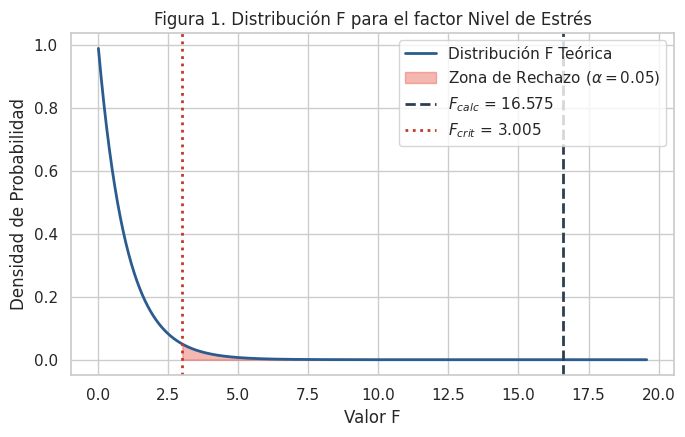

/tmp/ipykernel_6270/2407830804.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stress_Level_Category', y='CGPA', data=df_temp_plot, order=['Low', 'Medium', 'High'], palette='Blues_r', width=0.5)


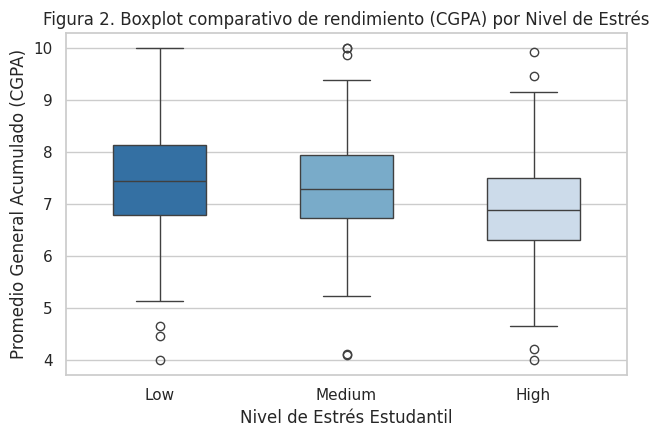

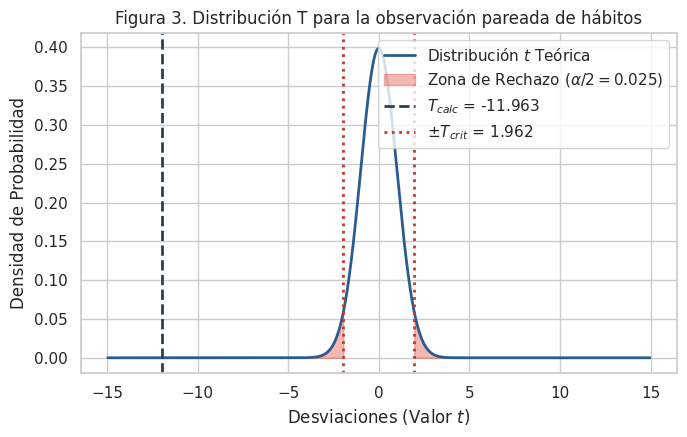

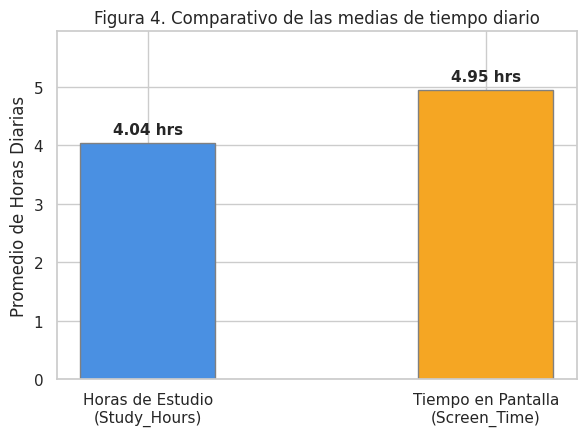

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats 

g_bajo = df[df['Stress_Level_1_to_10'] <= 4]['CGPA'].values
g_medio = df[(df['Stress_Level_1_to_10'] > 4) & (df['Stress_Level_1_to_10'] <= 7)]['CGPA'].values
g_alto = df[df['Stress_Level_1_to_10'] > 7 ]['CGPA'].values
g_tot = [g_bajo, g_medio, g_alto]

k = 3
n_dims = [len(g) for g in g_tot]
N_tot = sum(n_dims)
yi_mean = np.array([np.mean(g) for g in g_tot])
y_mean = np.mean(np.concatenate(g_tot))

SSA_val = SSA(k, n_dims, yi_mean, y_mean)
SSE_val = SSE(k, g_tot, yi_mean)
SST_val = SSA_val + SSE_val

df1, df2 = k - 1, N_tot - k
MSA, MSE = SSA_val / df1, SSE_val / df2
f_exp = MSA / MSE

f_critico = stats.f.ppf(0.95, df1, df2)


diferencias = df['Study_Hours_per_Day'].values - df['Screen_Time_Hours'].values
n_dif = len(diferencias)
df_t = n_dif - 1
media_dif = np.mean(diferencias)
desv_dif = np.std(diferencias, ddof=1)
t_exp = media_dif / (desv_dif / np.sqrt(n_dif))


t_critico = stats.t.ppf(0.975, df_t) 


print("=====================================================================")
print("             DATOS CALCULADOS PARA TU CUADRO I (ANOVA)")
print("=====================================================================")
print(f"Suma de Cuadrados Tratamientos (SSA): {SSA_val:.4f}")
print(f"Suma de Cuadrados Error (SSE):        {SSE_val:.4f}")
print(f"Suma de Cuadrados Total (SST):        {SST_val:.4f}")
print(f"Grados de libertad (df1, df2):        {df1}, {df2}")
print(f"Estadístico F Experimental (F_calc):  {f_exp:.4f}")
print(f"Valor Crítico F de Tabla (F_crit):    {f_critico:.4f}")
print("=====================================================================")
print("             DATOS CALCULADOS PARA PRUEBA PAREADA T")
print("=====================================================================")
print(f"Estadístico T Experimental (T_calc):  {t_exp:.4f}")
print(f"Valor Crítico T de Tabla (T_crit):    {t_critico:.4f}")
print("=====================================================================\n")

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.titlesize': 14})

plt.figure(figsize=(7, 4.5))
x_f = np.linspace(0.01, max(f_exp, f_critico) + 3, 1000)

y_f = [stats.f.pdf(val, df1, df2) for val in x_f]
plt.plot(x_f, y_f, label='Distribución F Teórica', color='#2b5c8f', lw=2)


x_rechazo = np.linspace(f_critico, max(x_f), 500)

y_rechazo = [stats.f.pdf(val, df1, df2) for val in x_rechazo]
plt.fill_between(x_rechazo, y_rechazo, color='#e74c3c', alpha=0.4, label='Zona de Rechazo ($\\alpha = 0.05$)')

plt.axvline(f_exp, color='#2c3e50', linestyle='--', lw=2, label=f'$F_{{calc}}$ = {f_exp:.3f}')
plt.axvline(f_critico, color='#c0392b', linestyle=':', lw=2, label=f'$F_{{crit}}$ = {f_critico:.3f}')
plt.title('Figura 1. Distribución F para el factor Nivel de Estrés')
plt.xlabel('Valor F')
plt.ylabel('Densidad de Probabilidad')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figura1_distribucion_F.pdf', format='pdf')
plt.show()


plt.figure(figsize=(6.5, 4.5))

df_temp_plot = df.copy()
bins = [0, 4, 7, 10]
labels = ['Low', 'Medium', 'High']
df_temp_plot['Stress_Level_Category'] = pd.cut(df_temp_plot['Stress_Level_1_to_10'], bins=bins, labels=labels, right=True, include_lowest=True)

sns.boxplot(x='Stress_Level_Category', y='CGPA', data=df_temp_plot, order=['Low', 'Medium', 'High'], palette='Blues_r', width=0.5)
plt.title('Figura 2. Boxplot comparativo de rendimiento (CGPA) por Nivel de Estrés')
plt.xlabel('Nivel de Estrés Estudantil')
plt.ylabel('Promedio General Acumulado (CGPA)')
plt.tight_layout()
plt.savefig('figura2_boxplot_cgpa.pdf', format='pdf')
plt.show()

plt.figure(figsize=(7, 4.5))
x_t = np.linspace(-max(abs(t_exp), t_critico) - 3, max(abs(t_exp), t_critico) + 3, 1000)

y_t = [stats.t.pdf(val, df_t) for val in x_t]
plt.plot(x_t, y_t, label='Distribución $t$ Teórica', color='#2b5c8f', lw=2)


x_r_inf = np.linspace(min(x_t), -t_critico, 500)

plt.fill_between(x_r_inf, [stats.t.pdf(v, df_t) for v in x_r_inf], color='#e74c3c', alpha=0.4, label='Zona de Rechazo ($\\alpha/2 = 0.025$)')
x_r_sup = np.linspace(t_critico, max(x_t), 500)

plt.fill_between(x_r_sup, [stats.t.pdf(v, df_t) for v in x_r_sup], color='#e74c3c', alpha=0.4)

plt.axvline(t_exp, color='#2c3e50', linestyle='--', lw=2, label=f'$T_{{calc}}$ = {t_exp:.3f}')
plt.axvline(t_critico, color='#c0392b', linestyle=':', lw=2, label=f'$\\pm T_{{crit}}$ = {t_critico:.3f}')
plt.axvline(-t_critico, color='#c0392b', linestyle=':', lw=2)
plt.title('Figura 3. Distribución T para la observación pareada de hábitos')
plt.xlabel('Desviaciones (Valor $t$)')
plt.ylabel('Densidad de Probabilidad')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figura3_distribucion_T.pdf', format='pdf')
plt.show()


plt.figure(figsize=(6, 4.5))
medias_tiempo = [df['Study_Hours_per_Day'].mean(), df['Screen_Time_Hours'].mean()]
etiquetas = ['Horas de Estudio\n(Study_Hours)', 'Tiempo en Pantalla\n(Screen_Time)']

bars = plt.bar(etiquetas, medias_tiempo, color=['#4a90e2', '#f5a623'], width=0.4, edgecolor='gray')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f'{yval:.2f} hrs', ha='center', va='bottom', fontweight='bold')

plt.title('Figura 4. Comparativo de las medias de tiempo diario')
plt.ylabel('Promedio de Horas Diarias')
plt.ylim(0, max(medias_tiempo) + 1)
plt.tight_layout()
plt.savefig('figura4_barras_tiempos.pdf', format='pdf')
plt.show()